# Polynomial Regression with Easy Explanations

This notebook teaches Polynomial Regression in a simple step-by-step way.

Dataset used: **Diabetes dataset** from scikit-learn (built-in).

Why this dataset?
- It is built into scikit-learn (no manual download needed)
- It is a real regression dataset
- It works well for comparing linear vs polynomial behavior

## Easy English Terms (Quick Glossary)

- Linear Regression: fits a straight line.
- Polynomial Regression: fits a curve by adding powers like $x^2$, $x^3$.
- Degree: the highest power used in polynomial features.
- Underfitting: model is too simple.
- Overfitting: model learns noise and performs worse on new data.
- RMSE: average prediction error in target units.
- R2: goodness of fit (closer to 1 is better).
- Pipeline: fixed sequence of preprocessing + model steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 1: Load Built-in Data

We load the diabetes dataset directly from scikit-learn.

Target column: `target` (a continuous value), so this is a regression task.

In [2]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (442, 11)
Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Step 2: Choose One Feature for Clear Curve Visualization

For easy plotting, we use one feature: **BMI**.

- Input feature: `bmi`
- Output target: `target`

In [3]:
feature_name = 'bmi'
X = df[[feature_name]].values
y = df['target'].values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('First 5 X values:', X[:5].ravel())

X shape: (442, 1)
y shape: (442,)
First 5 X values: [ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469]


## Step 3: Split Data into Train and Test Sets

- Training data: teaches the model
- Testing data: checks performance on unseen samples

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 353
Test size: 89


## Step 4: Baseline Linear Regression

First we train a simple linear model (straight line). This gives us a baseline to compare against polynomial regression.

In [5]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

print('Linear model trained.')

Linear model trained.


In [17]:
linear_model.score(X_test, y_test)

0.23335039815872138

## Step 5: Polynomial Degree Search

We test degrees 2 to 5 and choose the one with the lowest RMSE on test data.

In [ ]:
degree_candidates = [2, 3, 4, 5]
search_rows = []

for degree in degree_candidates:
    poly_candidate = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])

    poly_candidate.fit(X_train, y_train)
    y_pred_candidate = poly_candidate.predict(X_test)

    rmse_candidate = np.sqrt(mean_squared_error(y_test, y_pred_candidate))
    r2_candidate = r2_score(y_test, y_pred_candidate)

    search_rows.append({
        'Degree': degree,
        'RMSE': rmse_candidate,
        'R2': r2_candidate
    })

degree_results = pd.DataFrame(search_rows).sort_values('RMSE').reset_index(drop=True)
degree_results

,Degree,RMSE,R2
0,3,63.752987,0.232856
1,2,63.914204,0.228972
2,5,63.920619,0.228817
3,4,65.008806,0.202336


In [19]:
poly_candidate = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LinearRegression())
])

poly_candidate.fit(X_train, y_train)
y_pred_candidate = poly_candidate.predict(X_test)

rmse_candidate = np.sqrt(mean_squared_error(y_test, y_pred_candidate))
r2_candidate = r2_score(y_test, y_pred_candidate)

r2_candidate

0.2328563664009029

In [8]:
best_degree = int(degree_results.loc[0, 'Degree'])

best_poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('model', LinearRegression())
])

best_poly_model.fit(X_train, y_train)
y_pred_poly = best_poly_model.predict(X_test)

print('Best polynomial degree:', best_degree)

Best polynomial degree: 3


## Step 6: Compare Important Scores

We compare linear vs best polynomial model using:
- MAE
- MSE
- RMSE
- R2

In [9]:
def regression_scores(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

mae_lin, mse_lin, rmse_lin, r2_lin = regression_scores(y_test, y_pred_linear)
mae_poly, mse_poly, rmse_poly, r2_poly = regression_scores(y_test, y_pred_poly)

scores_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Linear Regression': [mae_lin, mse_lin, rmse_lin, r2_lin],
    f'Polynomial (degree={best_degree})': [mae_poly, mse_poly, rmse_poly, r2_poly]
})

scores_df

,Metric,Linear Regression,Polynomial (degree=3)
0,MAE,52.259976,52.181400
1,MSE,4061.825928,4064.443384
2,RMSE,63.732456,63.752987
3,R2,0.233350,0.232856


## Step 7: Visualize Curves, Residuals, and Key Scores

Charts shown below:
1. Data + fitted curves
2. Residual comparison
3. Key score bar chart

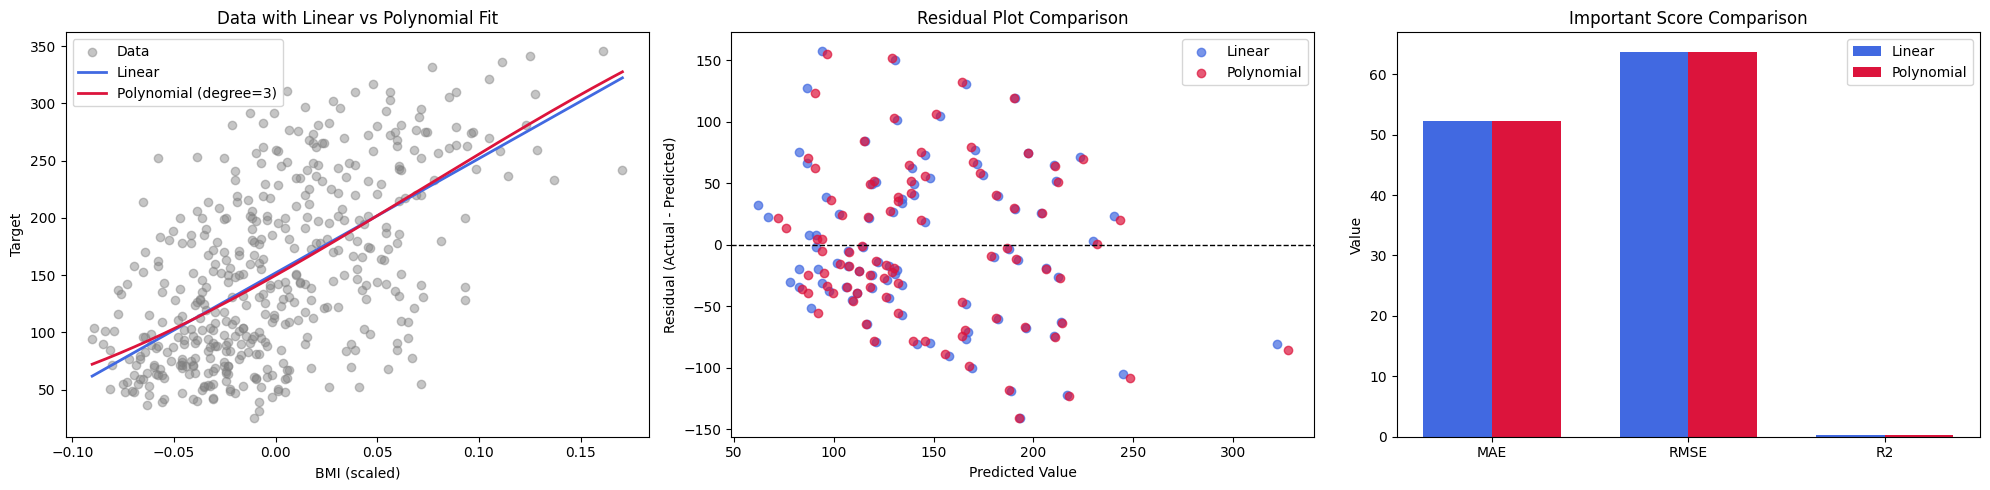

In [10]:
# Smooth x values for drawing clean model curves
X_curve = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_curve_linear = linear_model.predict(X_curve)
y_curve_poly = best_poly_model.predict(X_curve)

residual_linear = y_test - y_pred_linear
residual_poly = y_test - y_pred_poly

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Data and fitted curves
axes[0].scatter(X, y, color='gray', alpha=0.45, label='Data')
axes[0].plot(X_curve, y_curve_linear, color='royalblue', linewidth=2, label='Linear')
axes[0].plot(X_curve, y_curve_poly, color='crimson', linewidth=2, label=f'Polynomial (degree={best_degree})')
axes[0].set_title('Data with Linear vs Polynomial Fit')
axes[0].set_xlabel('BMI (scaled)')
axes[0].set_ylabel('Target')
axes[0].legend()

# 2) Residual comparison
axes[1].scatter(y_pred_linear, residual_linear, color='royalblue', alpha=0.7, label='Linear')
axes[1].scatter(y_pred_poly, residual_poly, color='crimson', alpha=0.7, label='Polynomial')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residual Plot Comparison')
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].legend()

# 3) Key score bars (lower is better for MAE/RMSE, higher is better for R2)
metric_names = ['MAE', 'RMSE', 'R2']
linear_vals = [mae_lin, rmse_lin, r2_lin]
poly_vals = [mae_poly, rmse_poly, r2_poly]

x_pos = np.arange(len(metric_names))
bar_width = 0.35

axes[2].bar(x_pos - bar_width / 2, linear_vals, width=bar_width, color='royalblue', label='Linear')
axes[2].bar(x_pos + bar_width / 2, poly_vals, width=bar_width, color='crimson', label='Polynomial')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(metric_names)
axes[2].set_title('Important Score Comparison')
axes[2].set_ylabel('Value')
axes[2].legend()

plt.tight_layout()
plt.show()

## Step 8: Make a Single Prediction

Example: predict target value for one BMI input.

`predict()` needs 2D input format, so we pass `[[value]]`.

In [11]:
sample_bmi = 0.05

linear_prediction = linear_model.predict([[sample_bmi]])[0]
poly_prediction = best_poly_model.predict([[sample_bmi]])[0]

print(f'Input BMI value: {sample_bmi}')
print(f'Linear prediction: {linear_prediction:.2f}')
print(f'Polynomial prediction (degree={best_degree}): {poly_prediction:.2f}')

Input BMI value: 0.05
Linear prediction: 201.93
Polynomial prediction (degree=3): 201.97


In [246]:
x = np.linspace(-20,50,51)

y = 7 * x**-1 + 0.001* np.random.normal(size=x.shape)

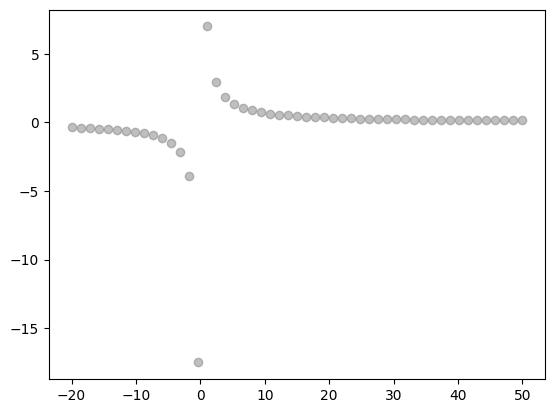

In [247]:
plt.scatter(x, y, color='gray', alpha=0.5, label='Data')

In [248]:
df = pd.DataFrame({
    'x': x,
    'y': y
})
df.drop(df.index[14], inplace=True)
df


,x,y
0,-20.0,-0.350784
1,-18.6,-0.376076
2,-17.2,-0.405754
3,-15.8,-0.444057
4,-14.4,-0.486933
5,-13.0,-0.536978
6,-11.6,-0.603202
7,-10.2,-0.686598
8,-8.8,-0.795594
9,-7.4,-0.946275


In [249]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x.reshape(-1, 1), y, test_size=0.2, random_state=42)

In [225]:
xtrain

array([[ -8.8],
       [ 48.6],
       [-11.6],
       [ 45.8],
       [-14.4],
       [ 30.4],
       [ 26.2],
       [  6.6],
       [ 47.2],
       [  1. ],
       [ -7.4],
       [  2.4],
       [ 16.4],
       [ 41.6],
       [ 15. ],
       [ -4.6],
       [-20. ],
       [ 43. ],
       [ 17.8],
       [ 27.6],
       [-13. ],
       [ 20.6],
       [ 31.8],
       [-18.6],
       [  9.4],
       [-17.2],
       [ 34.6],
       [ 29. ],
       [ 12.2],
       [ 37.4],
       [ -6. ],
       [ 10.8],
       [  5.2],
       [ 50. ],
       [  8. ],
       [-10.2],
       [ 38.8],
       [ -0.4],
       [ 19.2],
       [ 33.2]])

In [256]:


model = LinearRegression()
model.fit(xtrain**-1, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [257]:
model.score(xtest**-2, ytest)

-1.0250449037015956

In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[['x']])

ndf = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['x']))
ndf = ndf.join(df['y'])
ndf.drop(14, inplace=True)
ndf

In [ ]:
ndf

In [206]:
features = ndf.drop(columns=['y'])
target = ndf['y']


xtrain, xtest, ytrain, ytest = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [198]:
pipe = Pipeline([
    # ('poly_features', PolynomialFeatures(degree=4, include_bias=False)),
    ('model', LinearRegression())
]) 

pipe.fit(xtrain, ytrain)

pipe.score(xtest, ytest)



-4.0157293593790655

In [120]:
pipe.predict(xtest)

array([ 271.05755817,  122.40413648,  206.41323312,   82.84547254,
         77.89539644,   53.12442232,  -31.32985152,  256.07475769,
        -90.99265831, -140.49564154,  -51.22836113,    8.45043171,
        221.27645671,   23.35327416,  306.24450783, -120.73538674,
        236.16655537,  241.13715941,  -81.05947498,   13.41919143])

In [27]:
pipe.predict([[0]])

c:\Users\hamen\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([-17.45843994])

In [74]:
degree_candidates = [1, 2, 3, 4, 5]
search_rows = []

for degree in degree_candidates:
    poly_candidate = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])

    poly_candidate.fit(xtrain, ytrain)
    y_pred_candidate = poly_candidate.predict(xtest)

    rmse_candidate = np.sqrt(mean_squared_error(ytest, y_pred_candidate))
    r2_candidate = r2_score(ytest, y_pred_candidate)

    search_rows.append({
        'Degree': degree,
        'RMSE': rmse_candidate,
        'R2': r2_candidate
    })

degree_results = pd.DataFrame(search_rows).sort_values('RMSE').reset_index(drop=True)
degree_results

,Degree,RMSE,R2
0,3,0.211406,1.000000
1,4,0.213062,1.000000
2,5,0.213080,1.000000
3,2,579.026771,0.991830
4,1,2683.331512,0.824549


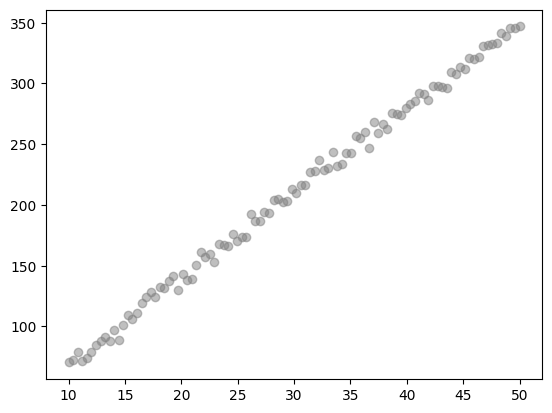

In [97]:
plt.plot(x, y, 'o', color='gray', alpha=0.5, label='Data')

In [126]:
ndf

,x,x^2,x^3,x^4,y
0,-20.000000,400.000000,-8000.000000,1.600000e+05,-138.187033
1,-19.292929,372.217121,-7181.158591,1.385456e+05,-138.239036
2,-18.585859,345.434139,-6420.190065,1.193247e+05,-134.760063
3,-17.878788,319.651056,-5714.973426,1.021768e+05,-122.467770
4,-17.171717,294.867871,-5063.387677,8.694706e+04,-118.794906
...,...,...,...,...,...
95,47.171717,2225.170901,104965.132397,4.951386e+06,335.303263
96,47.878788,2292.378329,109756.295740,5.254998e+06,332.973572
97,48.585859,2360.585655,114691.080791,5.572365e+06,344.091759
98,49.292929,2429.792878,119771.608545,5.903893e+06,348.699226


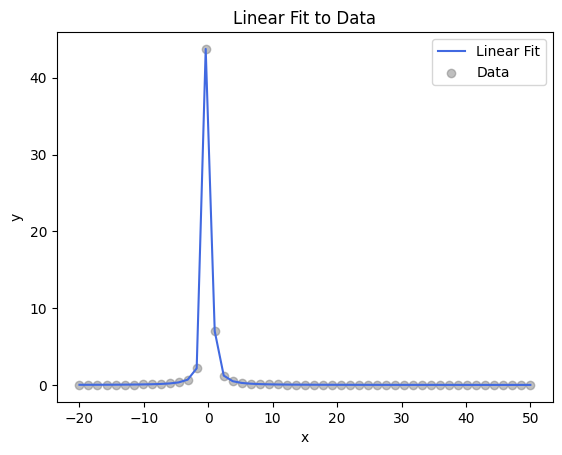

In [228]:
plt.plot(x, model.predict(x.reshape(-1, 1)**-2), color='royalblue', label='Linear Fit')
plt.scatter(x, y, color='gray', alpha=0.5, label='Data')
plt.title('Linear Fit to Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [245]:
model.predict([[0.001**-2]])

array([7000425.54927954])